# Proyecto RappiPlus: de datos a decisiones de negocio

**Introducción**


El objetivo de este proyecto es evaluar el desempeño del servicio **RappiPlus** para apoyar **decisiones de negocio basadas en datos**.

Se trabajan con múltiples datasets del negocio:

- **rappiplus_orders_raw.csv** → información de pedidos, precios, descuentos y revenue  
- **rappiplus_catalog.csv** → costos de productos, categorías y proveedores  
- **rappiplus_marketing_spend.csv** → inversión en marketing por canal y país  
- **events / users / user_activity (SQL)** → comportamiento del usuario dentro de la plataforma  
- **experiment_checkout_ui.csv** → resultados de un experimento A/B en el checkout  

El análisis sigue una lógica clara y progresiva:

1. 🔍 Evaluar si podemos confiar en los datos (calidad de datos en Python) 

2. 💰 Analizar si el negocio es rentable (revenue, costos y profit)  

3. 🛒 Entender dónde se pierden los usuarios (funnel de conversión)  

4. 🔁 Evaluar si los usuarios regresan (retención por cohortes)  

5. 🧪 Validar si los cambios generan impacto (test estadístico)  

6. 📊 Comunicar los resultados (dashboard en BI)  

A lo largo del proyecto, se transforman datos en insights para responder preguntas clave del negocio y proponer **recomendaciones accionables**.

---

## Paso 1: Cargar y validar la calidad de los datos


In [1]:
# importar librerías
import pandas as pd

In [2]:
# cargar archivos
orders = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_orders_raw.csv')
catalog = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_catalog.csv')
marketing = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_marketing_spend.csv')

In [3]:
# explorar datasets
print("ORDERS")
print(orders.shape)
print(orders.info())
print(orders.head())

ORDERS
(25100, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25100 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_pedido           25100 non-null  object 
 1   id_usuario          25100 non-null  object 
 2   fecha_hora_pedido   25100 non-null  object 
 3   pais                24800 non-null  object 
 4   dispositivo         25080 non-null  object 
 5   fuente_referencia   25070 non-null  object 
 6   nombre_producto     25070 non-null  object 
 7   categoria_producto  25020 non-null  object 
 8   cantidad            25050 non-null  float64
 9   precio_unitario     25050 non-null  float64
 10  monto_descuento     25050 non-null  float64
 11  monto_total         25100 non-null  float64
dtypes: float64(4), object(8)
memory usage: 2.3+ MB
None
  id_pedido id_usuario fecha_hora_pedido       pais dispositivo  \
0   order_0  user_6993        2025-05-22  Argentina     deskto

In [4]:
print("CATALOG")
print(catalog.shape)
print(catalog.info())
print(catalog.head())

CATALOG
(7, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   nombre_producto     7 non-null      object 
 1   categoria_producto  7 non-null      object 
 2   costo_unitario      7 non-null      float64
 3   proveedor           7 non-null      object 
dtypes: float64(1), object(3)
memory usage: 352.0+ bytes
None
        nombre_producto categoria_producto  costo_unitario  \
0    Laptop-Gaming-16GB        Electrónica          280.68   
1       Phone-Pro-128GB        Electrónica           10.12   
2  Tablet-Standard-64GB        Electrónica           25.21   
3        Blender-XL-Red              Hogar          176.64   
4      Vacuum-Pro-Black              Hogar           16.60   

                 proveedor  
0   Fuller, Pena and Myers  
1                 King Ltd  
2               Bowers LLC  
3                Long-Reid  
4  Rivera, 

In [5]:
print("MARKETING")
print(marketing.shape)
print(marketing.info())
print(marketing.head())

MARKETING
(1620, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   fecha       1620 non-null   object 
 1   pais        1620 non-null   object 
 2   id_campaña  1620 non-null   object 
 3   canal       1519 non-null   object 
 4   gasto       1620 non-null   float64
dtypes: float64(1), object(4)
memory usage: 63.4+ KB
None
        fecha      pais            id_campaña        canal    gasto
0  2025-01-01    Mexico        organic_Mexico      organic  2446.25
1  2025-01-01    Mexico    paid_search_Mexico  paid_search  2704.34
2  2025-01-01    Mexico         social_Mexico       social  2045.01
3  2025-01-01  Colombia      organic_Colombia      organic  2597.21
4  2025-01-01  Colombia  paid_search_Colombia  paid_search  1771.40


---

### Revisión y calidad de datos


In [6]:
# ======================
# Tratamiento de nulos
# ======================

print("Shape orders ANTES:", orders.shape)

orders['monto_descuento'] = orders['monto_descuento'].fillna(0)

orders = orders.dropna(subset=[
    'pais', 'dispositivo', 'fuente_referencia',
    'nombre_producto', 'categoria_producto',
    'cantidad', 'precio_unitario'
])

print("Shape orders DESPUÉS:", orders.shape)

marketing['canal'] = marketing['canal'].fillna('desconocido')

print("\nNulos restantes en orders:\n", orders.isnull().sum())
print("\nNulos restantes en marketing:\n", marketing.isnull().sum())

Shape orders ANTES: (25100, 12)
Shape orders DESPUÉS: (24700, 12)

Nulos restantes en orders:
 id_pedido             0
id_usuario            0
fecha_hora_pedido     0
pais                  0
dispositivo           0
fuente_referencia     0
nombre_producto       0
categoria_producto    0
cantidad              0
precio_unitario       0
monto_descuento       0
monto_total           0
dtype: int64

Nulos restantes en marketing:
 fecha         0
pais          0
id_campaña    0
canal         0
gasto         0
dtype: int64


In [7]:
# ======================
# Fechas y duplicados
# ======================

# Convertir fecha a datetime
orders['fecha_hora_pedido'] = pd.to_datetime(orders['fecha_hora_pedido'], errors='coerce')
print("Fechas no convertibles (NaT):", orders['fecha_hora_pedido'].isna().sum())
print("Rango de fechas:", orders['fecha_hora_pedido'].min(), "→", orders['fecha_hora_pedido'].max())

# Duplicados
print("\nFilas duplicadas exactas:", orders.duplicated().sum())
print("id_pedido duplicados:", orders['id_pedido'].duplicated().sum())

Fechas no convertibles (NaT): 0
Rango de fechas: 2025-01-01 00:00:00 → 2025-06-30 00:00:00

Filas duplicadas exactas: 100
id_pedido duplicados: 100


In [8]:
# ======================
# Eliminar duplicados
# ======================

print("Shape orders ANTES:", orders.shape)

orders = orders.drop_duplicates()

print("Shape orders DESPUÉS:", orders.shape)
print("id_pedido duplicados restantes:", orders['id_pedido'].duplicated().sum())

Shape orders ANTES: (24700, 12)
Shape orders DESPUÉS: (24600, 12)
id_pedido duplicados restantes: 0


In [9]:
# ======================
# Validación de negativos/ceros inválidos
# ======================

print("cantidad <= 0:", (orders['cantidad'] <= 0).sum())
print("precio_unitario <= 0:", (orders['precio_unitario'] <= 0).sum())
print("monto_total < 0:", (orders['monto_total'] < 0).sum())
print("monto_descuento < 0:", (orders['monto_descuento'] < 0).sum())

print("\nValores únicos en categoria_producto:")
print(orders['categoria_producto'].unique())
print("\nValores únicos en categoria_producto (catalog):")
print(catalog['categoria_producto'].unique())

cantidad <= 0: 0
precio_unitario <= 0: 0
monto_total < 0: 0
monto_descuento < 0: 0

Valores únicos en categoria_producto:
['Moda' 'Electronica' 'Hogar']

Valores únicos en categoria_producto (catalog):
['Electrónica' 'Hogar' 'Moda']


In [10]:
# ======================
# Estandarizar categoría (quitar tildes / unificar con orders)
# ======================

catalog['categoria_producto'] = catalog['categoria_producto'].replace('Electrónica', 'Electronica')

print("Valores únicos en categoria_producto (catalog) DESPUÉS:")
print(catalog['categoria_producto'].unique())

Valores únicos en categoria_producto (catalog) DESPUÉS:
['Electronica' 'Hogar' 'Moda']


---
**📦 Exportación**: Una vez finalizada la limpieza, se exportan los datasets para utilizarlos en la última etapa del proyecto.

In [11]:
# exportar datasets
orders.to_csv('orders_clean.csv', index=False)
catalog.to_csv('catalog_clean.csv', index=False)
marketing.to_csv('marketing_clean.csv', index=False)

---

## Paso 2: Analizar si el negocio es rentable


In [12]:
# Limpieza previa (duplicado seguro, no afecta el resultado si ya estaba filtrado)
orders = orders[orders['cantidad'] <= 20]

In [13]:
# ======================
# Parte 1: Rentabilidad del negocio
# ======================
revenue_total = orders['monto_total'].sum()
orders_cost = orders.merge(catalog[['nombre_producto', 'costo_unitario']], on='nombre_producto', how='left')
orders_cost['costo_total_linea'] = orders_cost['cantidad'] * orders_cost['costo_unitario']
costo_total = orders_cost['costo_total_linea'].sum()
marketing_total = marketing['gasto'].sum()
profit = revenue_total - costo_total - marketing_total
print(f"Revenue total: ${revenue_total:,.2f}")
print(f"Costo total (COGS): ${costo_total:,.2f}")
print(f"Inversión en marketing: ${marketing_total:,.2f}")
print(f"Profit: ${profit:,.2f}")
print(f"Margen de profit: {(profit / revenue_total) * 100:.2f}%")

Revenue total: $9,491,675.14
Costo total (COGS): $3,783,478.80
Inversión en marketing: $2,871,843.53
Profit: $2,836,352.81
Margen de profit: 29.88%


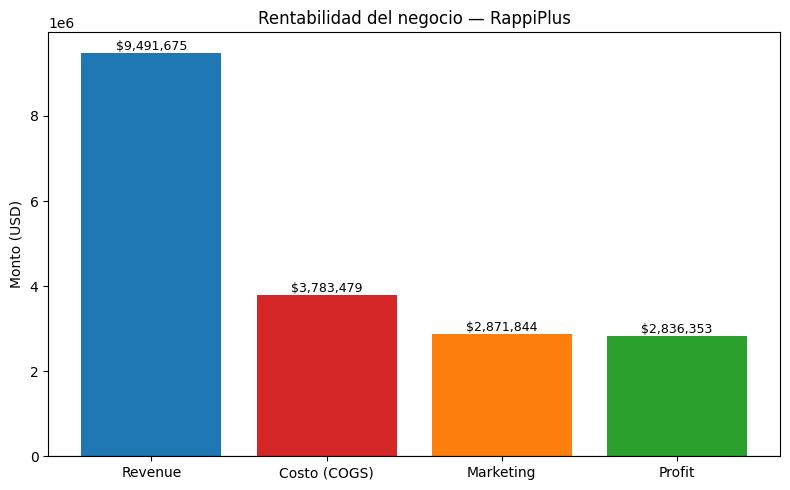

In [14]:
import matplotlib.pyplot as plt

conceptos = ['Revenue', 'Costo (COGS)', 'Marketing', 'Profit']
valores = [revenue_total, costo_total, marketing_total, profit]
colores = ['#1f77b4', '#d62728', '#ff7f0e', '#2ca02c']

plt.figure(figsize=(8,5))
barras = plt.bar(conceptos, valores, color=colores)
plt.title('Rentabilidad del negocio — RappiPlus')
plt.ylabel('Monto (USD)')

for barra, val in zip(barras, valores):
    plt.text(barra.get_x() + barra.get_width()/2, val, f'${val:,.0f}',
              ha='center', va='bottom' if val >= 0 else 'top', fontsize=9)

plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

### Interpretación de la rentabilidad

El negocio genera un Revenue total de **\$9,491,675.14**, con un Profit de **\$2,836,352.81** y un margen de profit de **29.88%**, después de restar COGS y gasto de marketing.

El Costo (COGS) representa el mayor gasto, **\$3,783,478.80** (39.9% del revenue), seguido de la inversión en marketing, **\$2,871,843.53** (30.3% del revenue). Juntos, costo y marketing consumen el 70.1% del revenue, dejando el 29.88% restante como margen de profit.

Sin un benchmark de la industria para este tipo de servicio, no puedo calificar ese margen como alto o bajo en términos absolutos. Lo que sí es cuantificable es la sensibilidad, un aumento en costos de producto o gasto de marketing sin un incremento proporcional en revenue reduciría directamente ese margen.


In [15]:
# ======================
# Parte 2: Comportamiento de ventas
# ======================

ticket_promedio = orders['monto_total'].mean()
cantidad_promedio = orders['cantidad'].mean()
producto_top = orders.groupby('nombre_producto')['cantidad'].sum().sort_values(ascending=False).head(1)

print(f"Ticket promedio por orden: ${ticket_promedio:,.2f}")
print(f"Cantidad promedio de productos por orden: {cantidad_promedio:.2f}")
print("Producto más vendido (unidades):")
print(producto_top)

Ticket promedio por orden: $386.00
Cantidad promedio de productos por orden: 1.51
Producto más vendido (unidades):
nombre_producto
Vacuum-Pro-Black    6203.0
Name: cantidad, dtype: float64


In [16]:
# Gasto en marketing por canal
gasto_por_canal = marketing.groupby('canal')['gasto'].sum().sort_values(ascending=False)
print("Gasto en marketing por canal:")
print(gasto_por_canal)

Gasto en marketing por canal:
canal
social         918043.21
organic        913533.01
paid_search    863088.21
desconocido    177179.10
Name: gasto, dtype: float64


In [17]:
# Verificación de outliers en cantidad
print(orders['cantidad'].describe())

count    24590.000000
mean         1.505205
std          0.499983
min          1.000000
25%          1.000000
50%          2.000000
75%          2.000000
max          2.000000
Name: cantidad, dtype: float64


In [18]:
# Diagnóstico de outliers en cantidad
print("Órdenes con cantidad > 20:", (orders['cantidad'] > 20).sum())
print("Órdenes con cantidad > 100:", (orders['cantidad'] > 100).sum())
print("Órdenes con cantidad > 1000:", (orders['cantidad'] > 1000).sum())

print("\nTop 10 órdenes con mayor cantidad:")
print(orders.sort_values('cantidad', ascending=False)[['id_pedido', 'nombre_producto', 'cantidad', 'monto_total']].head(10))

Órdenes con cantidad > 20: 0
Órdenes con cantidad > 100: 0
Órdenes con cantidad > 1000: 0

Top 10 órdenes con mayor cantidad:
         id_pedido       nombre_producto  cantidad  monto_total
0          order_0       Jacket-Winter-M       2.0       665.37
14211  order_14211    Laptop-Gaming-16GB       2.0       462.81
14144  order_14144        Blender-XL-Red       2.0       507.90
14146  order_14146  Tablet-Standard-64GB       2.0       583.51
14148  order_14148       Phone-Pro-128GB       2.0       970.99
14154  order_14154     Sneakers-Urban-42       2.0       387.03
14158  order_14158  Tablet-Standard-64GB       2.0        41.14
14159  order_14159       Jacket-Winter-M       2.0       755.16
14161  order_14161       Jacket-Winter-M       2.0       974.00
14162  order_14162  Tablet-Standard-64GB       2.0       483.37


In [19]:
# ======================
# Verificación de outliers de cantidad (umbral de control de calidad)
# ======================

print("Shape orders ANTES:", orders.shape)

orders = orders[orders['cantidad'] <= 20]

print("Shape orders DESPUÉS:", orders.shape)
print("\nNueva descripción de cantidad:")
print(orders['cantidad'].describe())

Shape orders ANTES: (24590, 12)
Shape orders DESPUÉS: (24590, 12)

Nueva descripción de cantidad:
count    24590.000000
mean         1.505205
std          0.499983
min          1.000000
25%          1.000000
50%          2.000000
75%          2.000000
max          2.000000
Name: cantidad, dtype: float64


In [20]:
# ======================
# Segmentos rentables
# ======================

# Revenue y profit por categoría de producto
orders_cost = orders.merge(catalog[['nombre_producto', 'costo_unitario']], on='nombre_producto', how='left')
orders_cost['costo_total_linea'] = orders_cost['cantidad'] * orders_cost['costo_unitario']

por_categoria = orders_cost.groupby('categoria_producto').agg(
    revenue=('monto_total', 'sum'),
    costo=('costo_total_linea', 'sum')
)
por_categoria['profit'] = por_categoria['revenue'] - por_categoria['costo']
por_categoria['margen_pct'] = (por_categoria['profit'] / por_categoria['revenue']) * 100
print("Rentabilidad por categoría:")
print(por_categoria.sort_values('profit', ascending=False))

# Revenue por país
print("\nRevenue por país:")
print(orders.groupby('pais')['monto_total'].sum().sort_values(ascending=False))

# Revenue por canal de adquisición (fuente_referencia)
print("\nRevenue por canal de adquisición:")
print(orders.groupby('fuente_referencia')['monto_total'].sum().sort_values(ascending=False))

Rentabilidad por categoría:
                       revenue       costo      profit  margen_pct
categoria_producto                                                
Hogar               3190241.62  1195311.56  1994930.06   62.532256
Electronica         3170376.62  1312562.04  1857814.58   58.599176
Moda                3131056.90  1275605.20  1855451.70   59.259597

Revenue por país:
pais
Mexico       2883459.32
Colombia     2848621.49
Argentina    2801928.24
mexico        321189.03
colombia      318248.21
argentina     318228.85
Name: monto_total, dtype: float64

Revenue por canal de adquisición:
fuente_referencia
social         3176164.92
paid_search    3167560.79
organic        3147949.43
Name: monto_total, dtype: float64


In [21]:
# ======================
# Estandarización de mayúsculas en el nombre del país
# ======================

print("Valores únicos ANTES:", orders['pais'].unique())

orders['pais'] = orders['pais'].str.title()

print("Valores únicos DESPUÉS:", orders['pais'].unique())

print("\nRevenue por país (corregido):")
print(orders.groupby('pais')['monto_total'].sum().sort_values(ascending=False))

Valores únicos ANTES: ['Argentina' 'Mexico' 'Colombia' 'mexico' 'argentina' 'colombia']
Valores únicos DESPUÉS: ['Argentina' 'Mexico' 'Colombia']

Revenue por país (corregido):
pais
Mexico       3204648.35
Colombia     3166869.70
Argentina    3120157.09
Name: monto_total, dtype: float64


In [22]:
print("Valores únicos en marketing.pais:", marketing['pais'].unique())

Valores únicos en marketing.pais: ['Mexico' 'Colombia' 'Argentina']


In [23]:
# ======================
# Re-exportación de datasets limpios (versión final)
# ======================

orders.to_csv('orders_clean.csv', index=False)
catalog.to_csv('catalog_clean.csv', index=False)
marketing.to_csv('marketing_clean.csv', index=False)

print("Datasets re-exportados con:")
print(f"- orders: {orders.shape[0]} filas (sin outliers de cantidad, países estandarizados)")
print(f"- catalog: {catalog.shape[0]} filas (categoría 'Electronica' unificada)")
print(f"- marketing: {marketing.shape[0]} filas (canal nulo → 'desconocido')")

Datasets re-exportados con:
- orders: 24590 filas (sin outliers de cantidad, países estandarizados)
- catalog: 7 filas (categoría 'Electronica' unificada)
- marketing: 1620 filas (canal nulo → 'desconocido')


---

## Paso 3: Entender dónde se pierden los usuarios (funnel de conversión)


In [24]:

import os
import pandas as pd
from sqlalchemy import create_engine

# Conexión a base de datos, credenciales gestionadas por variables de entorno
# (no se exponen en este notebook público)
db_config = {
    'user': os.environ.get('DB_USER'),
    'pwd': os.environ.get('DB_PWD'),
    'host': os.environ.get('DB_HOST'),
    'port': 5432,
    'db': os.environ.get('DB_NAME')
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

engine = create_engine(connection_string, connect_args={'sslmode': 'require'})


In [25]:

# Explorar tabla events
# =========================
query_events = '''
SELECT *
FROM events;
'''
events = pd.read_sql(query_events, con=engine)
events.head()


,id_usuario,id_sesion,nombre_evento,timestamp_evento,pais,dispositivo,fuente_referencia,categoria_producto
0,user_6772,6a97f2af-32ae-4186-8c92-04025be1a27b,first_visit,2025-05-17,Colombia,desktop,organic,Moda
1,user_5883,369b767c-1c33-4b2f-a652-c7c0ef92cfc9,add_to_cart,2025-02-23,Mexico,mobile,social,Hogar
2,user_5946,60039041-e78b-474c-87b3-c0b7e9c30708,add_payment_info,2025-05-15,Colombia,desktop,social,Electronica
3,user_827,18252a64-f389-4ef7-9e58-dadad4a3491e,purchase,2025-03-31,Mexico,mobile,social,Moda
4,user_2361,221b364e-cdc5-4668-b698-18d5ba849a67,first_visit,2025-01-22,Argentina,desktop,paid_search,Electronica


In [26]:
# ======================
# Auditoría de calidad de events
# ======================

print("Shape events:", events.shape)
print("\nNulos por columna:")
print(events.isnull().sum())
print("\nFilas duplicadas exactas:", events.duplicated().sum())
print("\nRango de fechas:", events['timestamp_evento'].min(), "→", events['timestamp_evento'].max())

Shape events: (120000, 8)

Nulos por columna:
id_usuario            0
id_sesion             0
nombre_evento         0
timestamp_evento      0
pais                  0
dispositivo           0
fuente_referencia     0
categoria_producto    0
dtype: int64

Filas duplicadas exactas: 0

Rango de fechas: 2025-01-01 → 2025-06-30


In [27]:
# ======================
# PARTE 1: Totales del funnel (usuarios únicos)
# ======================

query_totals = '''
SELECT 
    nombre_evento,
    COUNT(DISTINCT id_usuario) AS usuarios_unicos
FROM events
GROUP BY nombre_evento
ORDER BY usuarios_unicos DESC;
'''
totals = pd.read_sql(query_totals, con=engine)
totals

,nombre_evento,usuarios_unicos
0,first_visit,7796
1,add_to_cart,7634
2,select_item,7582
3,begin_checkout,7208
4,add_payment_info,6250
5,purchase,6240


In [28]:
query_check = '''
SELECT nombre_evento, COUNT(*) as total
FROM events
GROUP BY nombre_evento
ORDER BY total DESC;
'''
check = pd.read_sql(query_check, con=engine)
check

,nombre_evento,total
0,first_visit,29957
1,add_to_cart,24157
2,select_item,23887
3,begin_checkout,17971
4,add_payment_info,12018
5,purchase,12010


In [29]:
# ======================
# PARTE 2: Tasas de conversión y drop-off
# ======================
funnel = totals.copy()

# Conversión acumulada respecto al evento inicial (first_visit)
funnel['tasa_conversion_pct'] = (funnel['usuarios_unicos'] / funnel['usuarios_unicos'].iloc[0]) * 100

# Drop-off entre etapas consecutivas (se mantiene, es información complementaria válida)
funnel['tasa_paso_a_paso_pct'] = (funnel['usuarios_unicos'] / funnel['usuarios_unicos'].shift(1)) * 100
funnel['drop_off_pct'] = 100 - funnel['tasa_paso_a_paso_pct']

print(funnel)

tasa_final = (funnel['usuarios_unicos'].iloc[-1] / funnel['usuarios_unicos'].iloc[0]) * 100
print(f"\nTasa de conversión final (first_visit → purchase): {tasa_final:.2f}%")

mayor_drop = funnel.loc[funnel['drop_off_pct'].idxmax()]
print(f"\nMayor punto de abandono: llegando a '{mayor_drop['nombre_evento']}' ({mayor_drop['drop_off_pct']:.2f}% de drop-off)")

      nombre_evento  usuarios_unicos  tasa_conversion_pct  \
0       first_visit             7796           100.000000   
1       add_to_cart             7634            97.922011   
2       select_item             7582            97.255003   
3    begin_checkout             7208            92.457671   
4  add_payment_info             6250            80.169318   
5          purchase             6240            80.041047   

   tasa_paso_a_paso_pct  drop_off_pct  
0                   NaN           NaN  
1             97.922011      2.077989  
2             99.318837      0.681163  
3             95.067265      4.932735  
4             86.709212     13.290788  
5             99.840000      0.160000  

Tasa de conversión final (first_visit → purchase): 80.04%

Mayor punto de abandono: llegando a 'add_payment_info' (13.29% de drop-off)


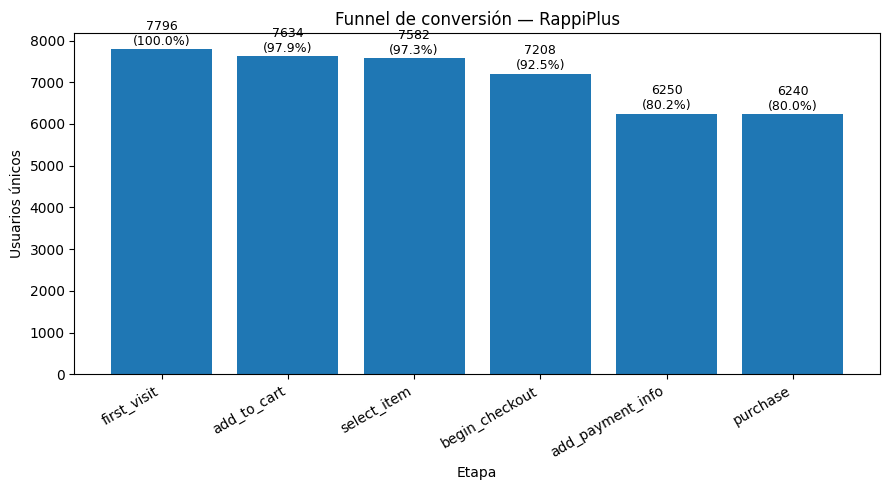

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))
plt.bar(funnel['nombre_evento'], funnel['usuarios_unicos'], color='#1f77b4')
plt.title('Funnel de conversión — RappiPlus')
plt.xlabel('Etapa')
plt.ylabel('Usuarios únicos')
plt.xticks(rotation=30, ha='right')

for i, val in enumerate(funnel['usuarios_unicos']):
    pct = funnel['tasa_conversion_pct'].iloc[i]
    plt.text(i, val + 100, f"{val}\n({pct:.1f}%)", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### Interpretación del funnel de conversión

El funnel muestra una conversión final de **80.04%** entre `first_visit` y `purchase`, sobre un total de 7,796 usuarios que iniciaron el recorrido.

**Nota metodológica.** Este cálculo compara usuarios únicos por evento, no la secuencia individual confirmada de cada usuario a través de las etapas. Es una aproximación razonable cuando el orden de los eventos es estable, pero no garantiza que cada usuario contado en una etapa haya pasado realmente por la etapa anterior en ese orden. Una versión más rigurosa requeriría rastrear la secuencia de eventos por usuario y por sesión.

Las primeras etapas (`add_to_cart`, `select_item`) muestran caídas bajas (2.08% y 0.68% respectivamente). El mayor punto de abandono está entre `begin_checkout` y `add_payment_info`, con un drop-off del 13.29%, la caída más grande de todo el funnel. Esa etapa es la prioridad para investigar. Las causas posibles, fricción en el formulario, falta de métodos de pago, o desconfianza en ese punto, son hipótesis a validar con datos cualitativos adicionales, no conclusiones que el dataset actual demuestre por sí solo.

De `add_payment_info` a `purchase` la caída es mínima (0.16%), la más baja del funnel.


In [31]:
# ======================
# Verificación del orden cronológico real del funnel
# ======================

query_orden = '''
SELECT 
    nombre_evento,
    MIN(timestamp_evento) AS primera_fecha,
    AVG(timestamp_evento::date - '2025-01-01'::date) AS dia_promedio_relativo
FROM events
GROUP BY nombre_evento
ORDER BY dia_promedio_relativo;
'''
orden_check = pd.read_sql(query_orden, con=engine)
orden_check

,nombre_evento,primera_fecha,dia_promedio_relativo
0,purchase,2025-01-01,89.513655
1,first_visit,2025-01-01,89.616751
2,add_payment_info,2025-01-01,89.729489
3,select_item,2025-01-01,90.281115
4,add_to_cart,2025-01-01,90.349630
5,begin_checkout,2025-01-01,90.507596


In [32]:
# ======================
# Orden real del funnel: secuencia dentro de cada sesión
# ======================

query_secuencia = '''
SELECT 
    id_sesion,
    nombre_evento,
    ROW_NUMBER() OVER (PARTITION BY id_sesion ORDER BY timestamp_evento) AS orden_en_sesion
FROM events
'''
secuencia = pd.read_sql(query_secuencia, con=engine)

# Promedio de la posición de cada evento dentro de su sesión
orden_real = secuencia.groupby('nombre_evento')['orden_en_sesion'].mean().sort_values()
print(orden_real)

nombre_evento
add_payment_info    1
add_to_cart         1
begin_checkout      1
first_visit         1
purchase            1
select_item         1
Name: orden_en_sesion, dtype: int64


In [33]:
# ======================
# Verificar cuántos eventos tiene cada sesión
# ======================

query_eventos_sesion = '''
SELECT id_sesion, COUNT(*) AS num_eventos
FROM events
GROUP BY id_sesion
ORDER BY num_eventos DESC
LIMIT 10;
'''
eventos_sesion = pd.read_sql(query_eventos_sesion, con=engine)
print(eventos_sesion)

query_promedio_sesion = '''
SELECT AVG(num_eventos) AS promedio_eventos_por_sesion
FROM (
    SELECT id_sesion, COUNT(*) AS num_eventos
    FROM events
    GROUP BY id_sesion
) sub;
'''
promedio_sesion = pd.read_sql(query_promedio_sesion, con=engine)
print(promedio_sesion)

                              id_sesion  num_eventos
0  16f12c35-8136-482a-b46c-b1fddeef0c6e            1
1  766f6792-28e6-43b1-a666-5da86b15a1e4            1
2  a3e34900-bb36-4644-aacd-f7a84db350ec            1
3  32cf4b8e-15dc-4aba-a8e7-fb0ca31f3211            1
4  efd93d72-b679-4578-9946-0de668890460            1
5  860576e0-730f-45c4-a1f3-59b4f20f88c5            1
6  decfdfba-b6d2-4d89-8be2-60fe056b6ee0            1
7  0b32d6b2-1a6b-4cb3-9333-5fde06308fe1            1
8  e98f2049-f1d5-4477-9742-eee8a36073c1            1
9  2bf0b7e0-819d-431b-9c0f-4f83fdfc0a95            1
   promedio_eventos_por_sesion
0                          1.0


---

## Paso 4: Evaluar si los usuarios regresan (retención por cohortes)


In [34]:
# ======================
# Paso 4: Cargar tablas users y user_activity
# ======================

query_users = '''
SELECT *
FROM users;
'''
users = pd.read_sql(query_users, con=engine)

query_activity = '''
SELECT *
FROM user_activity;
'''
user_activity = pd.read_sql(query_activity, con=engine)

print("USERS")
print(users.shape)
print(users.head())

print("\nUSER_ACTIVITY")
print(user_activity.shape)
print(user_activity.head())

USERS
(8000, 5)
  id_usuario fecha_registro       país dispositivo tipo_plan
0     user_0     2025-01-29     Mexico      mobile      free
1     user_1     2025-01-07     Mexico      mobile      free
2     user_2     2025-03-12  Argentina      mobile      free
3     user_3     2025-03-04     Mexico     desktop      free
4     user_4     2025-02-27  Argentina     desktop      free

USER_ACTIVITY
(32000, 4)
  id_usuario fecha_actividad  dias_despues_registro  activo
0     user_0      2025-02-05                      7       0
1     user_0      2025-02-12                     14       1
2     user_0      2025-02-19                     21       1
3     user_0      2025-02-26                     28       0
4     user_1      2025-01-14                      7       0


In [35]:
# ======================
# Auditoría de calidad: users y user_activity
# ======================

print("USERS - nulos:")
print(users.isnull().sum())
print("USERS - duplicados:", users.duplicated().sum())
print("USERS - id_usuario duplicados:", users['id_usuario'].duplicated().sum())

print("\nUSER_ACTIVITY - nulos:")
print(user_activity.isnull().sum())
print("USER_ACTIVITY - duplicados:", user_activity.duplicated().sum())

print("\nRango fecha_registro:", users['fecha_registro'].min(), "→", users['fecha_registro'].max())
print("Valores únicos dias_despues_registro:", sorted(user_activity['dias_despues_registro'].unique()))
print("Valores únicos activo:", user_activity['activo'].unique())

USERS - nulos:
id_usuario        0
fecha_registro    0
país              0
dispositivo       0
tipo_plan         0
dtype: int64
USERS - duplicados: 0
USERS - id_usuario duplicados: 0

USER_ACTIVITY - nulos:
id_usuario               0
fecha_actividad          0
dias_despues_registro    0
activo                   0
dtype: int64
USER_ACTIVITY - duplicados: 0

Rango fecha_registro: 2025-01-01 → 2025-05-31
Valores únicos dias_despues_registro: [7, 14, 21, 28]
Valores únicos activo: [0 1]


In [36]:

# Explorar tabla user_activity
# =========================
query_user_activity = '''
SELECT *
FROM user_activity;
'''
user_activity = pd.read_sql(query_user_activity, con=engine)
user_activity.head(3)

,id_usuario,fecha_actividad,dias_despues_registro,activo
0,user_0,2025-02-05,7,0
1,user_0,2025-02-12,14,1
2,user_0,2025-02-19,21,1


In [37]:
# Retención por cohortes
# ======================

query_cohort_retention_final = '''
SELECT
    DATE_TRUNC('month', CAST(u.fecha_registro AS DATE)) AS cohorte,
    COUNT(DISTINCT u.id_usuario) AS usuarios_totales,
    SUM(CASE WHEN a.dias_despues_registro = 7 AND a.activo = 1 THEN 1 ELSE 0 END) AS retenido_w1,
    SUM(CASE WHEN a.dias_despues_registro = 14 AND a.activo = 1 THEN 1 ELSE 0 END) AS retenido_w2,
    SUM(CASE WHEN a.dias_despues_registro = 21 AND a.activo = 1 THEN 1 ELSE 0 END) AS retenido_w3
FROM users u
JOIN user_activity a ON u.id_usuario = a.id_usuario
GROUP BY cohorte
ORDER BY cohorte;
'''

# Ejecutar la consulta
cohorte_final = pd.read_sql(query_cohort_retention_final, con=engine)
cohorte_final

,cohorte,usuarios_totales,retenido_w1,retenido_w2,retenido_w3
0,2025-01-01 00:00:00+00:00,1627,697,668,656
1,2025-02-01 00:00:00+00:00,1444,611,609,635
2,2025-03-01 00:00:00+00:00,1636,677,705,690
3,2025-04-01 00:00:00+00:00,1606,680,697,663
4,2025-05-01 00:00:00+00:00,1687,695,676,706


In [38]:

# ======================
# Porcentaje de retención por semana
# ======================

cohorte_final['semana_1'] = (cohorte_final['retenido_w1'] / cohorte_final['usuarios_totales']) * 100
cohorte_final['semana_2'] = (cohorte_final['retenido_w2'] / cohorte_final['usuarios_totales']) * 100
cohorte_final['semana_3'] = (cohorte_final['retenido_w3'] / cohorte_final['usuarios_totales']) * 100

cohorte_final


,cohorte,usuarios_totales,retenido_w1,retenido_w2,retenido_w3,semana_1,semana_2,semana_3
0,2025-01-01 00:00:00+00:00,1627,697,668,656,42.839582,41.057160,40.319607
1,2025-02-01 00:00:00+00:00,1444,611,609,635,42.313019,42.174515,43.975069
2,2025-03-01 00:00:00+00:00,1636,677,705,690,41.381418,43.092910,42.176039
3,2025-04-01 00:00:00+00:00,1606,680,697,663,42.341220,43.399751,41.282690
4,2025-05-01 00:00:00+00:00,1687,695,676,706,41.197392,40.071132,41.849437


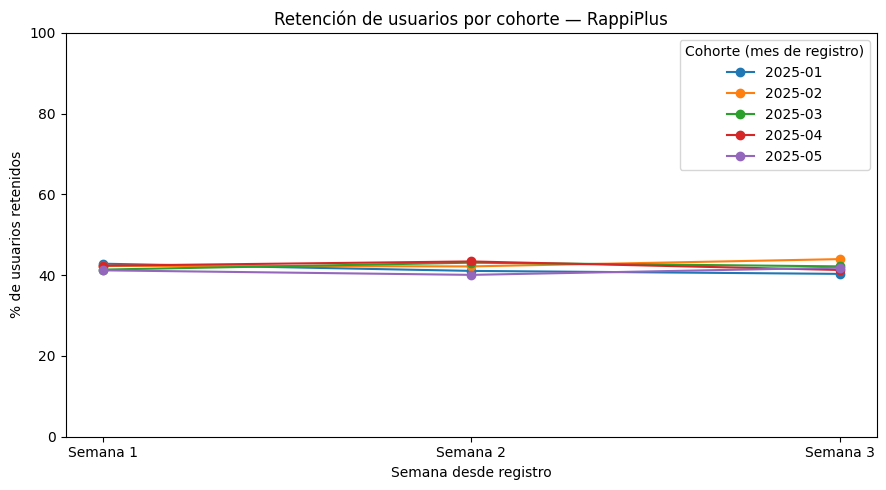

In [39]:
# ======================
# Gráfico de retención por cohortes
# ======================
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))

for _, row in cohorte_final.iterrows():
    etiqueta_cohorte = row['cohorte'].strftime('%Y-%m')
    valores_retencion = [row['semana_1'], row['semana_2'], row['semana_3']]
    plt.plot(['Semana 1', 'Semana 2', 'Semana 3'], valores_retencion, marker='o', label=etiqueta_cohorte)

plt.title('Retención de usuarios por cohorte — RappiPlus')
plt.xlabel('Semana desde registro')
plt.ylabel('% de usuarios retenidos')
plt.ylim(0, 100)
plt.legend(title='Cohorte (mes de registro)')
plt.tight_layout()
plt.show()

---

## Paso 5: Validar si los cambios generan impacto (test estadístico)


Hipótesis estadística
   - **H₀ (Hipótesis nula):** No existe diferencia en la tasa de conversión entre el grupo control y el grupo tratamiento (la nueva UI de checkout no tiene impacto).
   - **H₁ (Hipótesis alternativa):** Existe una diferencia en la tasa de conversión entre el grupo control y el grupo tratamiento (la nueva UI de checkout sí tiene impacto).
   
**Test estadístico:** Test de proporciones de dos muestras (two-proportion z-test), adecuado porque la métrica es binaria (convirtió / no convirtió) y comparamos dos grupos independientes.
**Nivel de significancia alpha:** 0.05

In [40]:
# Cargar y explorar dataset del experimento
# =========================
experimento = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/experiment_checkout_ui.csv')

print(experimento.shape)
print(experimento.info())
print(experimento.head())
print("\nVariantes:", experimento['variante'].unique())
print("\nNulos:\n", experimento.isnull().sum())
print("\nDuplicados:", experimento.duplicated().sum())



(10000, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_usuario       10000 non-null  object 
 1   variante         10000 non-null  object 
 2   convirtio        10000 non-null  int64  
 3   dispositivo      10000 non-null  object 
 4   pais             10000 non-null  object 
 5   duracion_sesion  10000 non-null  float64
 6   timestamp        10000 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 547.0+ KB
None
   id_usuario     variante  convirtio dispositivo       pais  duracion_sesion  \
0  exp_user_0  tratamiento          0      mobile  Argentina           114.41   
1  exp_user_1  tratamiento          0     desktop     Mexico           170.03   
2  exp_user_2      control          1      mobile   Colombia           140.21   
3  exp_user_3  tratamiento          0      mobile   Colombia           151.

In [41]:
# Tasas de conversión por variante
# =========================
tasas = experimento.groupby('variante')['convirtio'].agg(['count', 'sum', 'mean'])
tasas.columns = ['usuarios', 'conversiones', 'tasa_conversion']
tasas

,usuarios,conversiones,tasa_conversion
variante,,,
control,4965,779,0.156898
tratamiento,5035,820,0.162860


In [42]:
# Test de proporciones (z-test)
# =========================
from statsmodels.stats.proportion import proportions_ztest

conversiones = [tasas.loc['tratamiento', 'conversiones'], tasas.loc['control', 'conversiones']]
usuarios = [tasas.loc['tratamiento', 'usuarios'], tasas.loc['control', 'usuarios']]

z_stat, p_value = proportions_ztest(conversiones, usuarios)

print(f"Estadístico z: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print(f"\nResultado: p-value ({p_value:.4f}) < alpha ({alpha}) → Se rechaza H₀. La diferencia es estadísticamente significativa.")
else:
    print(f"\nResultado: p-value ({p_value:.4f}) >= alpha ({alpha}) → No se rechaza H₀. La diferencia NO es estadísticamente significativa.")

Estadístico z: 0.8133
P-value: 0.4161

Resultado: p-value (0.4161) >= alpha (0.05) → No se rechaza H₀. La diferencia NO es estadísticamente significativa.


**Interpretación del resultado:**
Con un p-value de 0.4161, muy por encima del nivel de significancia (α = 0.05), no hay evidencia estadística suficiente para rechazar H₀. La diferencia observada entre control (15.69%) y tratamiento (16.29%) es consistente con variación aleatoria a este tamaño de muestra. Esto no demuestra que la nueva UI no tenga ningún efecto, solo que este experimento no logró detectar uno con significancia estadística.

**Recomendación de negocio:** No se recomienda implementar el cambio de UI basándose en este experimento. Antes de descartarlo por completo, conviene calcular el poder estadístico y el tamaño de muestra necesario para detectar un efecto de la magnitud observada (~0.6 pp), ya que la muestra actual (10,000 usuarios) podría ser insuficiente para ese efecto.


In [43]:
# ======================
# Verificación de balance entre grupos (SRM check)
# ======================

print("Distribución de dispositivo por variante:")
print(pd.crosstab(experimento['variante'], experimento['dispositivo'], normalize='index') * 100)

print("\nDistribución de país por variante:")
print(pd.crosstab(experimento['variante'], experimento['pais'], normalize='index') * 100)

print("\nDuración de sesión promedio por variante:")
print(experimento.groupby('variante')['duracion_sesion'].mean())

print("\nRango de fechas del experimento:", experimento['timestamp'].min(), "→", experimento['timestamp'].max())

Distribución de dispositivo por variante:
dispositivo    desktop     mobile
variante                         
control      50.513595  49.486405
tratamiento  50.327706  49.672294

Distribución de país por variante:
pais         Argentina   Colombia     Mexico
variante                                    
control      33.353474  32.870091  33.776435
tratamiento  32.989076  32.691162  34.319762

Duración de sesión promedio por variante:
variante
control        161.042506
tratamiento    158.698779
Name: duracion_sesion, dtype: float64

Rango de fechas del experimento: 2025-01-01 → 2025-06-30


In [44]:
import os
print("Carpeta donde se guardaron los archivos:")
print(os.getcwd())
print("\nArchivos CSV en esa carpeta:")
for f in os.listdir():
    if f.endswith('.csv'):
        print(f)

Carpeta donde se guardaron los archivos:
/app

Archivos CSV en esa carpeta:
marketing_clean.csv
orders_clean.csv
catalog_clean.csv


## Paso 6: Comunicar los resultados (Dashboard en Power BI)


---